# 04 Results and Error Analysis

Loads the standardized full-run outputs and summarizes model quality.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUTPUT_TABLES = PROJECT_ROOT / 'outputs' / 'tables'
OUTPUT_FIGURES = PROJECT_ROOT / 'outputs' / 'figures'
OUTPUT_TRANSLATIONS = PROJECT_ROOT / 'outputs' / 'translations'
for path in [OUTPUT_TABLES, OUTPUT_FIGURES, OUTPUT_TRANSLATIONS]:
    path.mkdir(parents=True, exist_ok=True)

final_results_path = OUTPUT_TABLES / 'final_results.csv'
samples_path = OUTPUT_TRANSLATIONS / 'sample_translations.csv'
bleu_plot_path = OUTPUT_FIGURES / 'bleu_comparison.png'

final_results = pd.read_csv(final_results_path)
samples = pd.read_csv(samples_path)
display(final_results)
display(samples.head(10))

,model,decoding,examples,bleu,bleu_summary
0,dictionary_position_baseline,position_dictionary,1000,4.688637,BLEU = 4.69 39.8/8.5/2.2/0.6 (BP = 1.000 ratio...
1,tiny_transformer_full_greedy,greedy,1000,6.464511,BLEU = 6.46 32.4/10.0/3.7/1.5 (BP = 1.000 rati...


,arabic_input,reference_english,baseline_output,transformer_output
0,قبل عدة سنوات، هنا في تيد، قدّم بيتر سكيلمان م...,"several years ago here at ted, peter skillman ...","before many years, here in ted,,, peter, form,...","in a few years ago, i've been here in a few ye..."
1,والفكرة غاية في البساطة. فريق مكوّن من اربعة ي...,and the idea's pretty simple: teams of four ha...,"and the very in simplicity. a, a of four we to...",and one of the most powerful attributes of the...
2,يجب ان تكون المارش مالو علي القمة.,the marshmallow has to be on top.,"we to be the the, money, on the.",you have to be aware of the quality.
3,ورغماً عن انها تبدو بسيطة للغاية، الا انها صعب...,"and, though it seems really simple, it's actua...","and the, about it look simple., the it difficu...","it's very simple, very simple, very simple, be..."
4,لذا فقد فكرت بان هذه فكرة مثيرة، وقمت بتضمينها...,"and so, i thought this was an interesting idea...","so we i that this idea interesting, and to,. i...","so i thought that this idea is a design, and i..."
5,وقد كان نجاحاً باهراً.,and it was a huge success.,"and was success, the,.",and it was a very successful success.
6,ومنذ ذلك الحين، قمت بعقد حوالي 70 ورشة عمل للت...,"and since then, i've conducted about 70 design...","and that,, i,, about 70 and,, to design throug...","and i did a company called the company, and i ..."
7,اذاً، في العادة، يبدا معظم الناس بتوجيه انفسهم...,"so, normally, most people begin by orienting t...","so, in,, it most people to add themselves this...","so, most people start to this task, most peopl..."
8,يتحدثون عنها، ويتعرفون علي كيف سيكون شكلها، وي...,"they talk about it, they figure out what it's ...","people about, and know on how it shape it, and...","you know how we're going to be able to put it,..."
9,ثم يقضون بعض الوقت في التخطيط، والتنظيم. انهم ...,"then they spend some time planning, organizing...","and it a some time in the planning, and, organ...",and then they're going to spend some time in t...


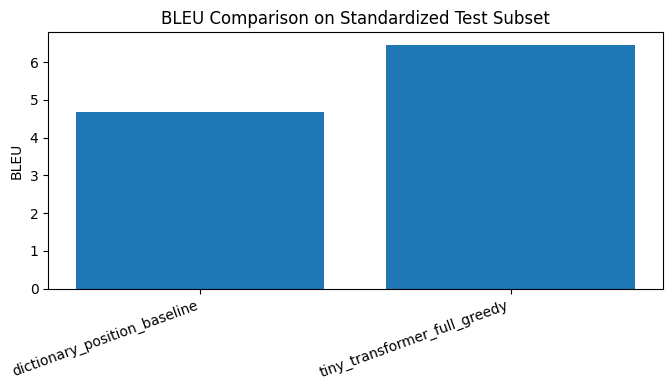

In [2]:
plt.figure(figsize=(7, 4))
plt.bar(final_results['model'], final_results['bleu'])
plt.ylabel('BLEU')
plt.title('BLEU Comparison on Standardized Test Subset')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(bleu_plot_path, dpi=200)
plt.show()

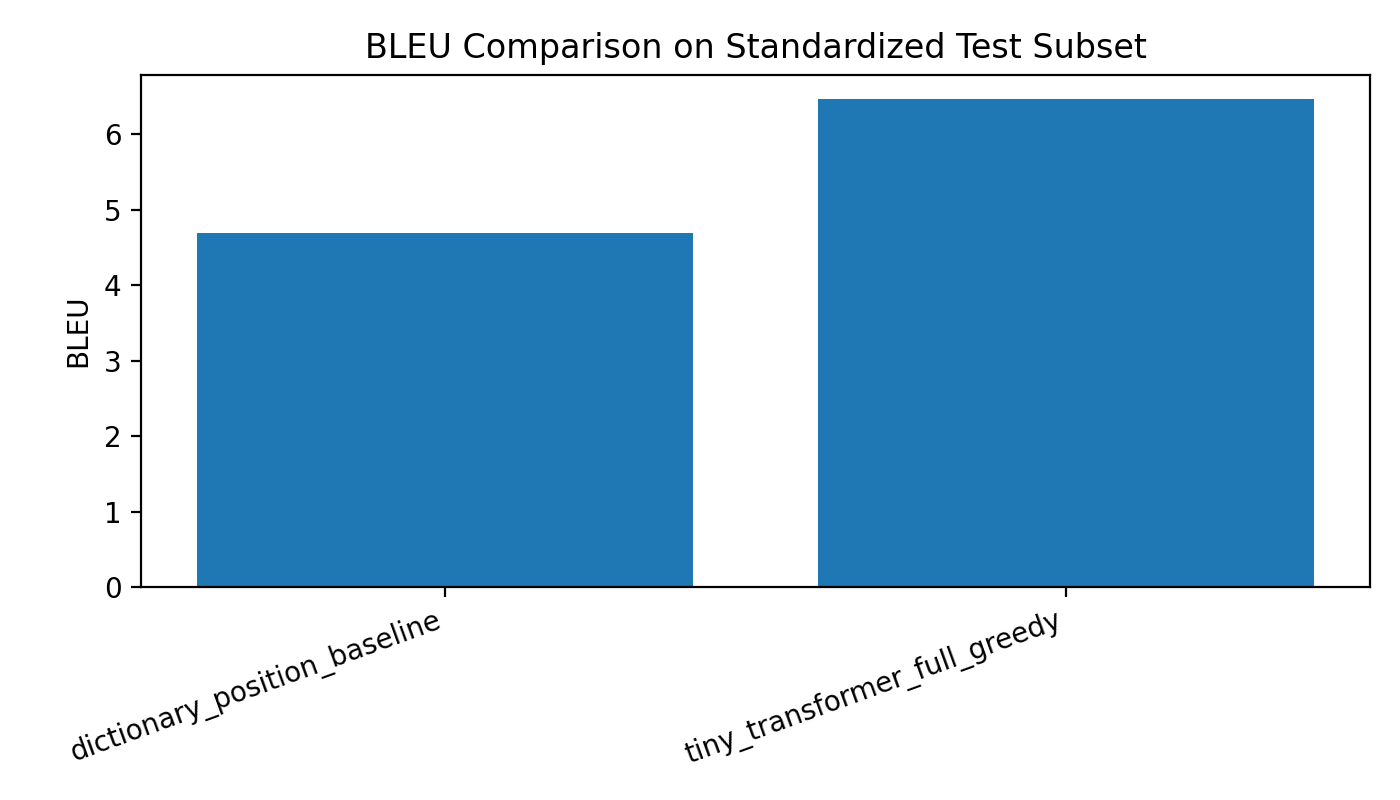

In [3]:
Image(filename=str(bleu_plot_path))

In [4]:
def error_category(reference, hypothesis):
    reference = '' if pd.isna(reference) else str(reference)
    hypothesis = '' if pd.isna(hypothesis) else str(hypothesis)
    ref_words = reference.split()
    hyp_words = hypothesis.split()
    lower = hypothesis.lower()
    if '<unk>' in lower or '?' in lower:
        return 'unknown/rare words'
    if not hyp_words or len(hyp_words) < max(2, 0.55 * len(ref_words)):
        return 'omissions'
    repeated_phrases = ['a lot of', 'the column', 'very simple', "i'm going to", 'the world']
    if any(lower.count(phrase) >= 2 for phrase in repeated_phrases):
        return 'generic phrase repetition'
    if any(ch.isdigit() for ch in reference) and not any(ch.isdigit() for ch in hypothesis):
        return 'named entity errors'
    return 'word order errors'

samples['error_category'] = [
    error_category(ref, hyp)
    for ref, hyp in zip(samples['reference_english'], samples['transformer_output'])
]
samples.to_csv(OUTPUT_TRANSLATIONS / 'sample_translations.csv', index=False)
error_summary = samples['error_category'].value_counts().rename_axis('error_category').reset_index(name='count')
error_summary.to_csv(OUTPUT_TABLES / 'error_analysis_summary.csv', index=False)
display(error_summary)
display(samples.head(10))

,error_category,count
0,word order errors,20
1,generic phrase repetition,2
2,unknown/rare words,2
3,named entity errors,1


,arabic_input,reference_english,baseline_output,transformer_output,error_category
0,قبل عدة سنوات، هنا في تيد، قدّم بيتر سكيلمان م...,"several years ago here at ted, peter skillman ...","before many years, here in ted,,, peter, form,...","in a few years ago, i've been here in a few ye...",word order errors
1,والفكرة غاية في البساطة. فريق مكوّن من اربعة ي...,and the idea's pretty simple: teams of four ha...,"and the very in simplicity. a, a of four we to...",and one of the most powerful attributes of the...,generic phrase repetition
2,يجب ان تكون المارش مالو علي القمة.,the marshmallow has to be on top.,"we to be the the, money, on the.",you have to be aware of the quality.,word order errors
3,ورغماً عن انها تبدو بسيطة للغاية، الا انها صعب...,"and, though it seems really simple, it's actua...","and the, about it look simple., the it difficu...","it's very simple, very simple, very simple, be...",generic phrase repetition
4,لذا فقد فكرت بان هذه فكرة مثيرة، وقمت بتضمينها...,"and so, i thought this was an interesting idea...","so we i that this idea interesting, and to,. i...","so i thought that this idea is a design, and i...",word order errors
5,وقد كان نجاحاً باهراً.,and it was a huge success.,"and was success, the,.",and it was a very successful success.,word order errors
6,ومنذ ذلك الحين، قمت بعقد حوالي 70 ورشة عمل للت...,"and since then, i've conducted about 70 design...","and that,, i,, about 70 and,, to design throug...","and i did a company called the company, and i ...",named entity errors
7,اذاً، في العادة، يبدا معظم الناس بتوجيه انفسهم...,"so, normally, most people begin by orienting t...","so, in,, it most people to add themselves this...","so, most people start to this task, most peopl...",word order errors
8,يتحدثون عنها، ويتعرفون علي كيف سيكون شكلها، وي...,"they talk about it, they figure out what it's ...","people about, and know on how it shape it, and...","you know how we're going to be able to put it,...",word order errors
9,ثم يقضون بعض الوقت في التخطيط، والتنظيم. انهم ...,"then they spend some time planning, organizing...","and it a some time in the planning, and, organ...",and then they're going to spend some time in t...,word order errors


In [5]:
transformer_bleu = final_results.loc[final_results['model'].str.contains('transformer'), 'bleu'].max()
baseline_bleu = final_results.loc[final_results['model'].str.contains('dictionary'), 'bleu'].max()
print(f'Transformer BLEU: {transformer_bleu:.4f}')
print(f'Dictionary baseline BLEU: {baseline_bleu:.4f}')
print('Transformer beats baseline:', transformer_bleu > baseline_bleu)
print('Generic phrase repetition count:', int((samples['error_category'] == 'generic phrase repetition').sum()))

Transformer BLEU: 6.4645
Dictionary baseline BLEU: 4.6886
Transformer beats baseline: True
Generic phrase repetition count: 2
